In [6]:
# Example of train and test data
# Overfitting if (accuracy on test data - accuracy on training data) > 5%

import pandas as pd
overall_data = pd.read_csv(r'datasets\Customer_profile_data.csv')


In [9]:
overall_data.head()

,Sr_no,Age,Gender,Bought
0,1,45,1,1
1,2,56,1,1
2,3,49,0,1
3,4,50,0,0
4,5,75,0,0


In [11]:
# Change the string values to numerical values

# overall_data['Gender'] = overall_data['Gender'].map({'Male': 1, 'Female': 0}).astype(int)
# overall_data['Bought'] = overall_data['Bought'].map({'Yes': 1, 'No': 0}).astype(int)

features = list(overall_data.columns[1:3])
print(features)

['Age', 'Gender']


In [10]:
print(overall_data['Gender'].unique())
print(overall_data['Bought'].unique())

[1 0]
[1 0]


In [12]:
x= overall_data[features]
y= overall_data['Bought']

print(x.shape)
print(y.shape)

(109, 2)
(109,)


In [5]:
overall_data.head(5)

,Sr_no,Age,Gender,Bought
0,1,45,1,1
1,2,56,1,1
2,3,49,0,1
3,4,50,0,0
4,5,75,0,0


In [13]:
# Dividing data to training and testing data

from sklearn import model_selection

X_train, X_test, y_train, y_test = model_selection.train_test_split(x, y, test_size=0.8, random_state=5)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(21, 2)
(88, 2)
(21,)
(88,)


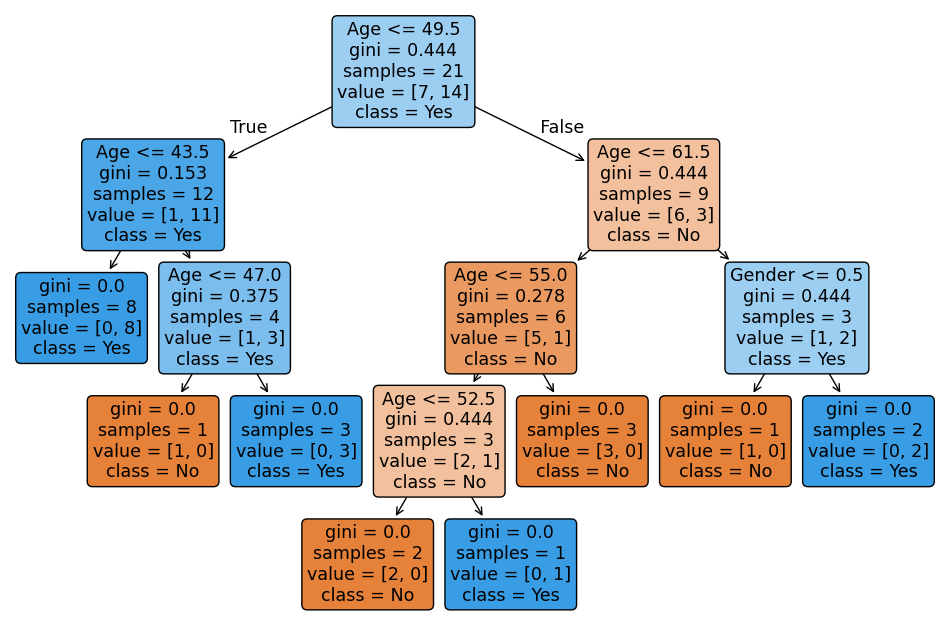

|--- Age <= 49.50
|   |--- Age <= 43.50
|   |   |--- class: 1
|   |--- Age >  43.50
|   |   |--- Age <= 47.00
|   |   |   |--- class: 0
|   |   |--- Age >  47.00
|   |   |   |--- class: 1
|--- Age >  49.50
|   |--- Age <= 61.50
|   |   |--- Age <= 55.00
|   |   |   |--- Age <= 52.50
|   |   |   |   |--- class: 0
|   |   |   |--- Age >  52.50
|   |   |   |   |--- class: 1
|   |   |--- Age >  55.00
|   |   |   |--- class: 0
|   |--- Age >  61.50
|   |   |--- Gender <= 0.50
|   |   |   |--- class: 0
|   |   |--- Gender >  0.50
|   |   |   |--- class: 1



In [17]:
from sklearn import tree
DTModel1 = tree.DecisionTreeClassifier()
DTModel1.fit(X_train, y_train)

#Plotting the decision tree
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(DTModel1, filled=True, rounded=True, feature_names=features, class_names=['No', 'Yes'])
plt.show()
print(export_text(DTModel1, feature_names=features))

In [ ]:
# finding accuracy of train and test data

from sklearn.metrics import confusion_matrix

#train accuracy
predict1 = DTModel1.predict(X_train)
cm1 = confusion_matrix(y_train, predict1)
total1 = sum(sum(cm1))
accuracy1 = (cm1[0,0] + cm1[1,1]) / total1
print("Training Accuracy: {:.2f}%".format(accuracy1*100))

#test accuracy
predict2 = DTModel1.predict(X_test)
cm2 = confusion_matrix(y_test, predict2)
total2 = sum(sum(cm2))
accuracy2 = (cm2[0,0] + cm2[1,1]) / total2
print("Testing Accuracy: {:.2f}%".format(accuracy2*100))

# as the accuracy of training data is 100% and that of test data is 72.73%, the model is overfitting

Training Accuracy: 100.00%
Testing Accuracy: 72.73%


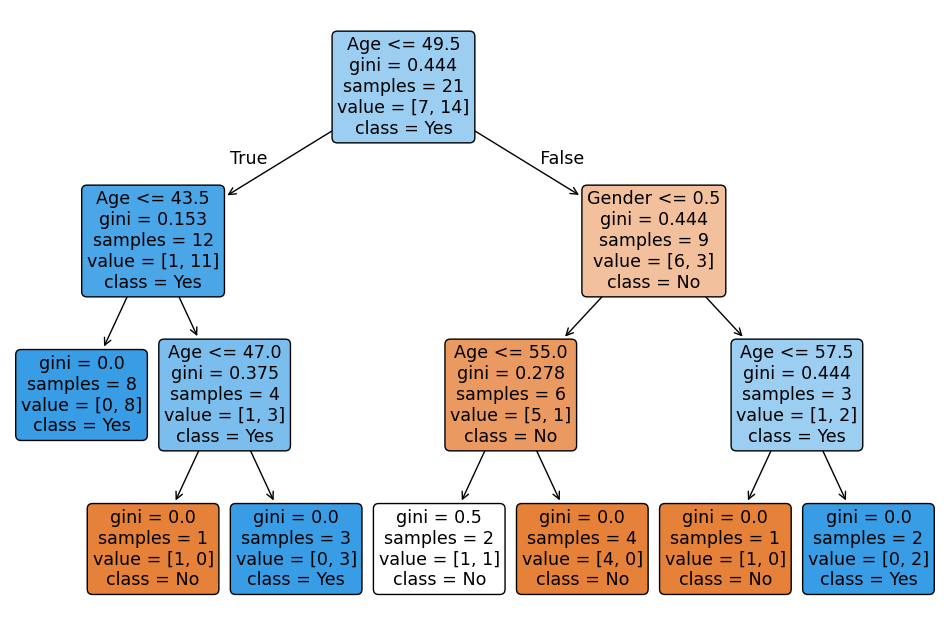

|--- Age <= 49.50
|   |--- Age <= 43.50
|   |   |--- class: 1
|   |--- Age >  43.50
|   |   |--- Age <= 47.00
|   |   |   |--- class: 0
|   |   |--- Age >  47.00
|   |   |   |--- class: 1
|--- Age >  49.50
|   |--- Gender <= 0.50
|   |   |--- Age <= 55.00
|   |   |   |--- class: 0
|   |   |--- Age >  55.00
|   |   |   |--- class: 0
|   |--- Gender >  0.50
|   |   |--- Age <= 57.50
|   |   |   |--- class: 0
|   |   |--- Age >  57.50
|   |   |   |--- class: 1



In [31]:
# Therefore, pruning the decision tree is necessary
# WE need to learn when to stop growing the decision tree

from sklearn import tree
DTModel2 = tree.DecisionTreeClassifier(max_depth=3)
DTModel2.fit(X_train, y_train)

#Plotting the decision tree
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
plot_tree(DTModel2, filled=True, rounded=True, feature_names=features, class_names=['No', 'Yes'])
plt.show()
print(export_text(DTModel2, feature_names=features))

# finding accuracy of train and test data at max_depth=2



In [32]:
#train accuracy
predict3 = DTModel2.predict(X_train)
cm1 = confusion_matrix(y_train, predict3)
total1 = sum(sum(cm1))
accuracy3 = (cm1[0,0] + cm1[1,1]) / total1
print("Training Accuracy: {:.2f}%".format(accuracy3*100))

#test accuracy
predict4 = DTModel2.predict(X_test)
cm2 = confusion_matrix(y_test, predict4)
total2 = sum(sum(cm2))
accuracy4 = (cm2[0,0] + cm2[1,1]) / total2
print("Testing Accuracy: {:.2f}%".format(accuracy4*100))

Training Accuracy: 95.24%
Testing Accuracy: 78.41%
